Imports and Load Data Set


In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

In [82]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path)

path = path + '/etfs'
all_files = glob.glob(os.path.join(path, "*.csv"))

Path to dataset files: /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2


The dataset contains stocks and ETFs - we want to specifically look at ETFs

In [83]:
# !Uncomment to view data in each csv
# Loop through each file and print data
max_rows = 0
max_df = None
max_file = None
for file in all_files:
    df = pd.read_csv(file)
    number_rows = len(df)    indices_to_drop = df[df.Open ==0].index    df = df.drop(indices_to_drop)    if len(df) > max_rows:
      max_rows = len(df)
      max_df = df
      max_file = file
    #print(f"Processing: {file}")
    # Perform your operations on df here
    #print(df.head())  # Example: print first 5 rows
print("Data Frame: " , max_df.head(), "\nRows: " , max_rows, " File: " , max_file)

Data Frame:           Date  Open    High     Low   Close  Adj Close  Volume
0  1986-04-03   0.0  4.7500  4.6250  4.6250   4.449552   15300
1  1986-04-04   0.0  4.7500  4.6875  4.7500   4.569811   12000
2  1986-04-07   0.0  4.8750  4.7500  4.7500   4.569811   11500
3  1986-04-08   0.0  4.8125  4.6875  4.7500   4.569811   21000
4  1986-04-09   0.0  4.8125  4.6250  4.6875   4.509681   22800 
Rows:  8568  File:  /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/etfs/CEF.csv


In [84]:
#TODO make it work with all data not just the largest file


#TODO split up the date vector into Day,Month,Year vectors
max_df = max_df.iloc[:, 1:] #removes date for now

Going to work with the largest file for now
Data cleaning started below

In [89]:
y_train = np.zeros(max_rows)

y_train = (max_df['Close'] - max_df['Open']).to_numpy()

for i in range(50):
  print(y_train[i])


print("Data Frame (first 5 rows):")
print(max_df.head())
print("\nRows:", max_rows)
print("File:", max_file)

4.625
4.75
4.75
4.75
4.6875
4.625
4.625
4.5625
4.625
4.5625
4.5
4.4375
4.375
4.375
4.5
4.5625
4.5625
4.5
4.4375
4.5
4.5625
4.5
4.5
4.5
4.375
4.4375
4.4375
4.3125
4.375
4.375
4.3125
4.4375
4.375
4.4375
4.4375
4.4375
4.4375
4.375
4.375
4.4375
4.375
4.375
4.3125
4.3125
4.3125
4.375
4.375
4.4375
4.5
4.625
Data Frame (first 5 rows):
   Open    High     Low   Close  Adj Close  Volume
0   0.0  4.7500  4.6250  4.6250   4.449552   15300
1   0.0  4.7500  4.6875  4.7500   4.569811   12000
2   0.0  4.8750  4.7500  4.7500   4.569811   11500
3   0.0  4.8125  4.6875  4.7500   4.569811   21000
4   0.0  4.8125  4.6250  4.6875   4.509681   22800

Rows: 8568
File: /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2/etfs/CEF.csv


Using Neural Networks

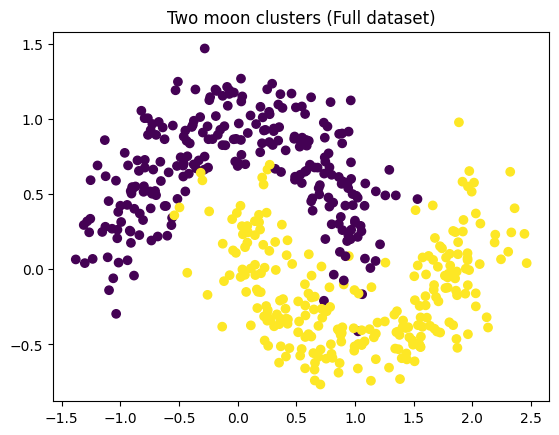

In [86]:
import sklearn.datasets
import sklearn.metrics
import tensorflow

X, y = sklearn.datasets.make_moons(n_samples=500, noise=0.19, random_state=96594) #TODO: Change random_state to the last 5 digits of your BuffOne card
X_train, y_train = X[:350], y[:350]
X_test, y_test = X[350:], y[350:]
plt.title("Two moon clusters (Full dataset)")
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

def show_decision_surface(model):
    """
    Helper function to visualize the decision surface of model
    :param model: Initialized Classifier
    :return: None
    """
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    x_grid = np.arange(x_min, x_max, 0.1)
    y_grid = np.arange(y_min, y_max, 0.1)
    xx, yy = np.meshgrid(x_grid, y_grid)
    r1, r2 = xx.reshape(-1,1), yy.reshape(-1,1)
    grid = np.hstack((r1,r2))
    y_hat = model.predict(grid)
    zz = y_hat.reshape(xx.shape)
    plt.contourf(xx, yy, zz, cmap='PiYG')
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.show()

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6817  
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5815 
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5005 
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4498 
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3852 
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3598 
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3106 
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3231  
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3297 
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2609 
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2328 
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2878 
Epoch 13/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2134 
Epoch 14/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2272 
Epoch 15/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2296 
Ep

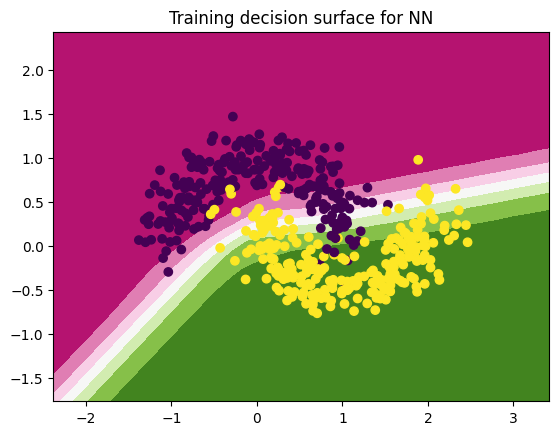

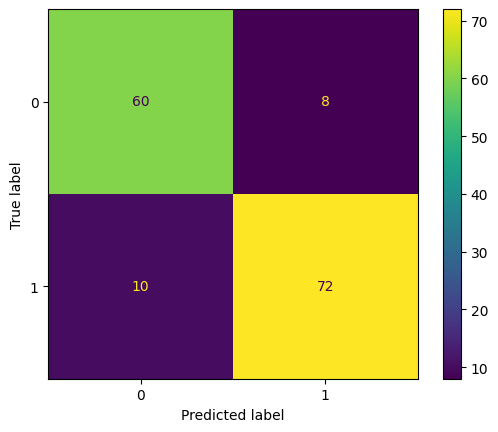

Accuracy: 0.88


In [87]:
model = tensorflow.keras.models.Sequential( [
    tensorflow.keras.layers.InputLayer(shape=(2,)),
    tensorflow.keras.layers.Dense(50, activation = "relu"),
    tensorflow.keras.layers.Dense(50, activation = "relu"),
    tensorflow.keras.layers.Dense(1, activation="sigmoid")
] )

model.compile(loss="BinaryCrossentropy")

model.fit(X_train, y_train, epochs=20)
score = model.evaluate(X_test, y_test, verbose=0)

y_pred = (model.predict(X_test) > 0.5).astype("int32")

plt.title("Training decision surface for NN")
show_decision_surface(model)
conf = sklearn.metrics.confusion_matrix(y_test, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(conf)
disp.plot()
plt.show()
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
print("Accuracy:" , accuracy)